# Combined Cycle Power Plant - Regression

**Problem statement:** Predict net hourly electrical energy output (`PE`, MW) from ambient temperature (`AT`), exhaust vacuum (`V`), ambient pressure (`AP`), and relative humidity (`RH`).

**Source:** UCI Machine Learning Repository, dataset 294. The local CSV is generated by `data/download.py`.

## 1. Setup and reproducibility

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "PE"
FEATURES = ["AT", "V", "AP", "RH"]

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Dataset loading and audit

In [2]:
data_path = Path("data/regression.csv")
if not data_path.exists():
    data_path = Path("../data/regression.csv")

df = pd.read_csv(data_path)
assert list(df.columns) == FEATURES + [TARGET], "Unexpected dataset columns"

print(f"Shape: {df.shape}")
display(df.head())

Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(),
})
display(audit)
print(f"Duplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_percent,unique_values
AT,float64,0,0.0,2773
V,float64,0,0.0,634
AP,float64,0,0.0,2517
RH,float64,0,0.0,4546
PE,float64,0,0.0,4836


Duplicate rows: 41


In [4]:
display(df.describe().T)
display(df[TARGET].describe().to_frame("target_distribution"))

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


,target_distribution
count,9568.000000
mean,454.365009
std,17.066995
min,420.260000
25%,439.750000
50%,451.550000
75%,468.430000
max,495.760000


### Audit observation

The dataset contains 9,568 observations, four continuous predictors, and one continuous target. All columns load as `float64` and no values are missing, so imputation is unnecessary. There are 41 exact duplicate rows; these must be removed before splitting to prevent identical observations appearing in both train and test sets. `PE` spans 420.26-495.76 MW, with mean 454.37 MW and standard deviation 17.07 MW.

## 3. Exploratory data analysis

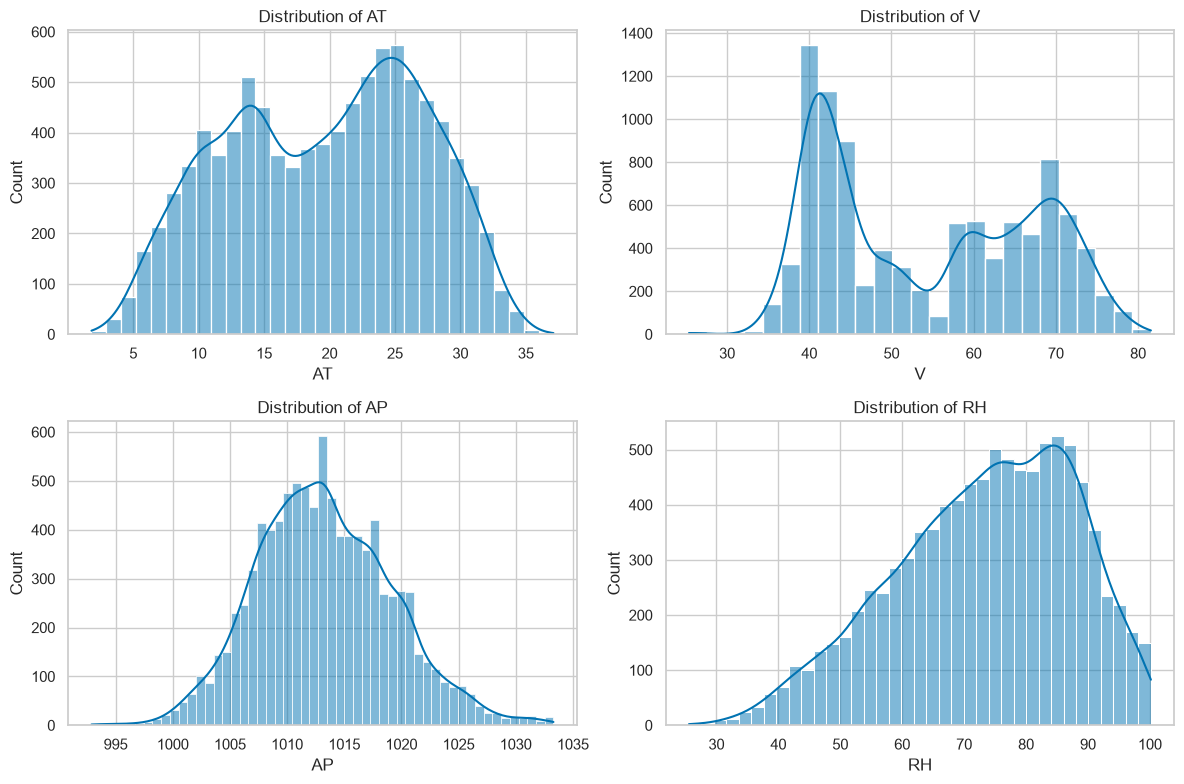

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for feature, axis in zip(FEATURES, axes.flat):
    sns.histplot(df[feature], kde=True, ax=axis)
    axis.set(title=f"Distribution of {feature}", xlabel=feature, ylabel="Count")
plt.tight_layout()

### Feature-distribution observation

The predictor distributions show only modest skew: `AT` is nearly symmetric (skew -0.136), while `V` and `AP` are mildly right-skewed (0.199 and 0.265). `RH` has a longer lower-humidity tail (skew -0.432). `AP` is tightly concentrated around 1,013 mbar, whereas temperature and vacuum cover broader operating ranges. None of the four predictors has pathological skew that would require a logarithmic transformation.

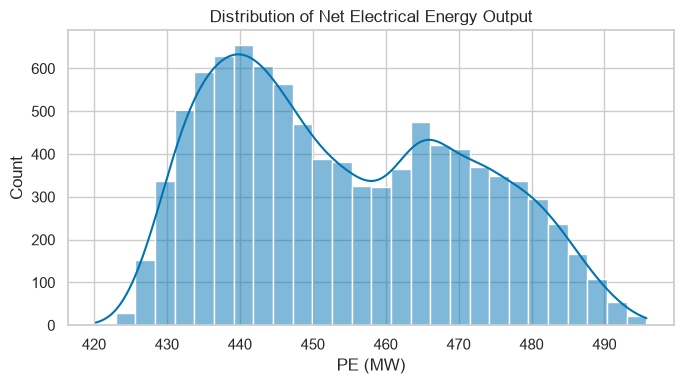

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(df[TARGET], kde=True)
plt.title("Distribution of Net Electrical Energy Output")
plt.xlabel("PE (MW)")
plt.ylabel("Count")
plt.tight_layout()

### Target-distribution observation

Electrical output is centred near 454 MW, with a median of 451.55 MW and mild positive skew (0.307). The target covers a useful 75.5 MW range and has no severe long tail, so R2, RMSE, and MAE can be interpreted directly in the original MW scale without transforming `PE`.

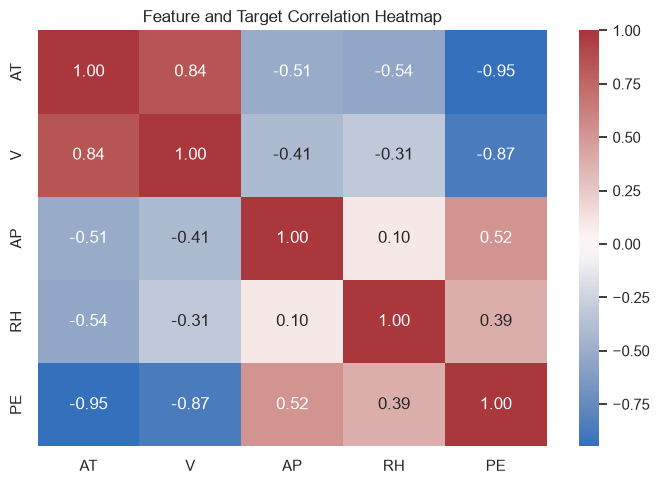

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Feature and Target Correlation Heatmap")
plt.tight_layout()

### Correlation observation

Ambient temperature has the strongest relationship with output (`r = -0.948`), followed by exhaust vacuum (`r = -0.870`). Pressure and humidity have weaker positive correlations with output (`r = 0.518` and `0.390`). `AT` and `V` are also strongly correlated (`r = 0.844`), so regularised linear models may be more stable than unregularised coefficients when these predictors carry overlapping information.

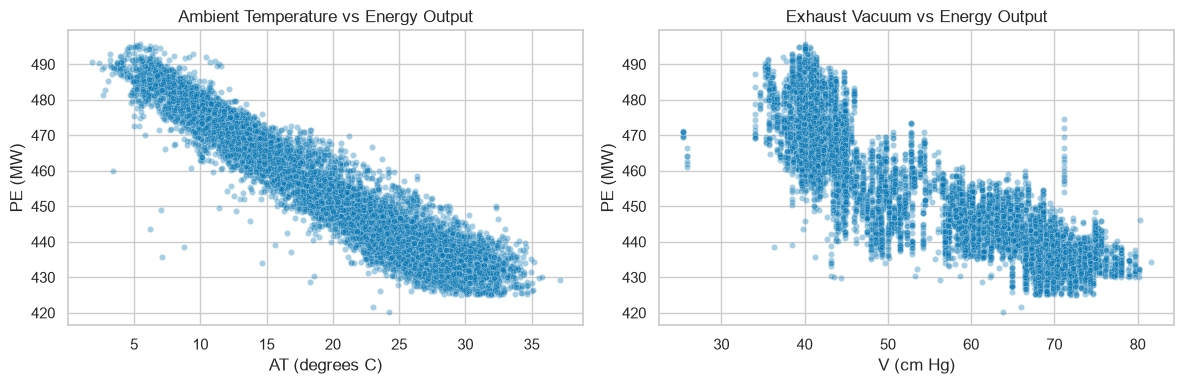

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="AT", y=TARGET, alpha=0.35, s=20, ax=axes[0])
axes[0].set(title="Ambient Temperature vs Energy Output", xlabel="AT (degrees C)", ylabel="PE (MW)")
sns.scatterplot(data=df, x="V", y=TARGET, alpha=0.35, s=20, ax=axes[1])
axes[1].set(title="Exhaust Vacuum vs Energy Output", xlabel="V (cm Hg)", ylabel="PE (MW)")
plt.tight_layout()

### Feature-target relationship observation

Both scatter plots show that output generally falls as ambient temperature or exhaust vacuum rises. The temperature relationship is especially strong but not perfectly linear, while the vacuum plot shows wider vertical spread at similar values. These patterns justify comparing linear baselines with polynomial, kernel, tree, and ensemble models that can represent interactions and curved responses.

## 4. Cleaning, outliers, feature engineering, and splitting

In [9]:
q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[FEATURES] < (q1 - 1.5 * iqr)) | (df[FEATURES] > (q3 + 1.5 * iqr))
outlier_summary = pd.DataFrame({
    "lower_bound": q1 - 1.5 * iqr,
    "upper_bound": q3 + 1.5 * iqr,
    "iqr_outlier_count": outlier_mask.sum(),
})
display(outlier_summary)

,lower_bound,upper_bound,iqr_outlier_count
AT,-4.80500,44.03500,0
V,4.54000,103.74000,0
AP,996.86000,1029.50000,88
RH,31.07375,117.08375,12


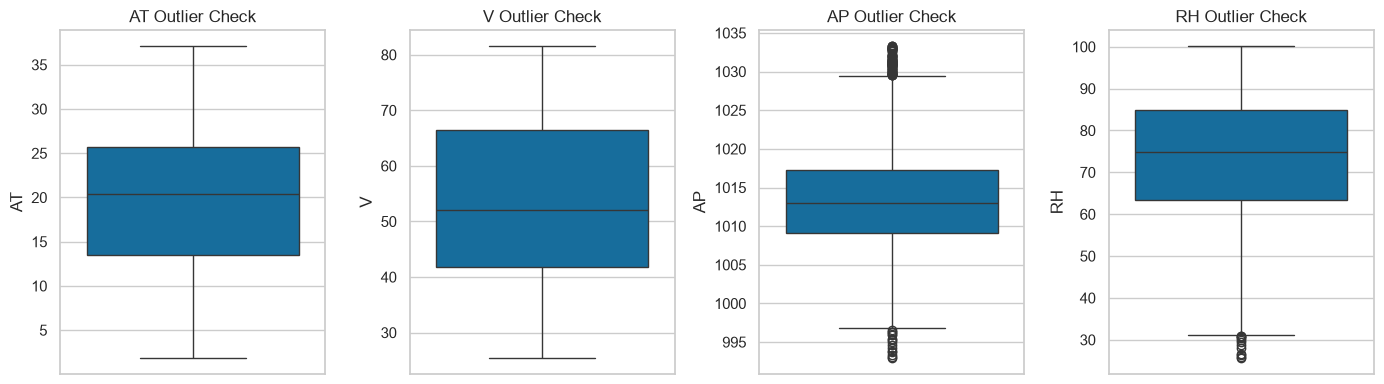

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for feature, axis in zip(FEATURES, axes):
    sns.boxplot(y=df[feature], ax=axis)
    axis.set(title=f"{feature} Outlier Check", xlabel="", ylabel=feature)
plt.tight_layout()

### Cleaning and outlier decision

Removing 41 exact duplicates leaves 9,527 unique rows. The IQR rule flags no `AT` or `V` values, 88 `AP` values, and 12 `RH` values. These pressure and humidity observations remain within the documented physical sensor ranges, so deleting or clipping them would discard legitimate operating conditions. They are retained; `RobustScaler`, fitted only within training folds, reduces their influence for scale-sensitive models, while tree models are not affected by feature magnitude.

In [11]:
clean_df = df.drop_duplicates().reset_index(drop=True)
assert clean_df.isna().sum().sum() == 0
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after duplicate removal: {len(clean_df):,}")

Rows before cleaning: 9,568
Rows after duplicate removal: 9,527


### Engineered feature

The engineered `AT_x_V` interaction represents their combined operating condition. Because both variables have strong individual relationships with output and are themselves correlated, their joint effect may not be fully represented by an additive linear equation. The interaction gives linear and regularised models a direct way to capture that dependence.

In [12]:
clean_df["AT_x_V"] = clean_df["AT"] * clean_df["V"]
MODEL_FEATURES = FEATURES + ["AT_x_V"]

X = clean_df[MODEL_FEATURES]
y = clean_df[TARGET]
display(X.head())

,AT,V,AP,RH,AT_x_V
0,14.96,41.76,1024.07,73.17,624.7296
1,25.18,62.96,1020.04,59.08,1585.3328
2,5.11,39.40,1012.16,92.14,201.3340
3,20.86,57.32,1010.24,76.64,1195.6952
4,10.82,37.50,1009.23,96.62,405.7500


In [13]:
from sklearn.model_selection import train_test_split

target_bins = pd.qcut(y, q=10, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "target_mean": [y_train.mean(), y_test.mean()],
    "target_std": [y_train.std(), y_test.std()],
}, index=["train", "test"])
display(split_summary.round(3))

,rows,target_mean,target_std
train,7621,454.332,17.035
test,1906,454.351,17.059


### Preprocessing justification

The continuous target is divided into ten quantile bins solely for stratification, preserving the full numeric `PE` values for training. This produces closely matched train and test target distributions: both means are approximately 454.36 MW and both standard deviations are approximately 17.06 MW. Scaling is placed inside each model pipeline so every scaler is fitted only on the current training fold, preventing information from validation or test observations leaking into model fitting.